--- Test 2 ---
<class 'pandas.core.frame.DataFrame'>
Index: 862 entries, 0 to 878
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   COVID_swab_res   862 non-null    int64  
 1   IgG_Test1_titre  862 non-null    float64
 2   IgG_Test2_titre  862 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 26.9 KB


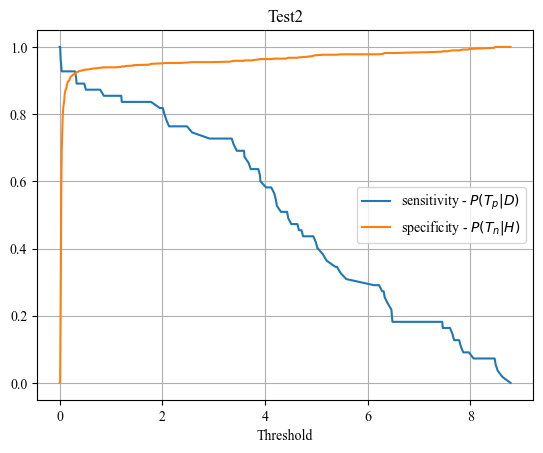

<Figure size 640x480 with 0 Axes>

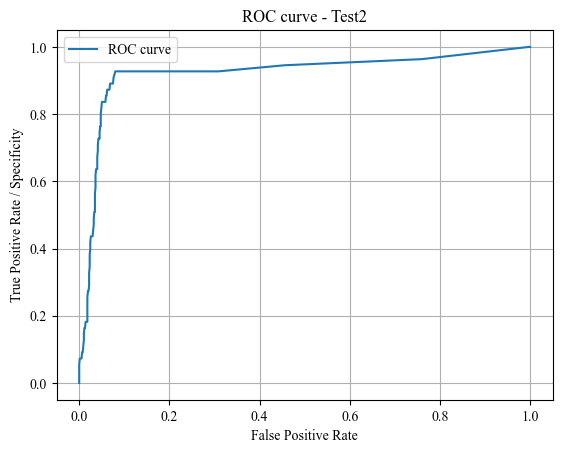

Manual AUC (Loop): 0.9215057552266855
Sklearn AUC: 0.9376791167488843


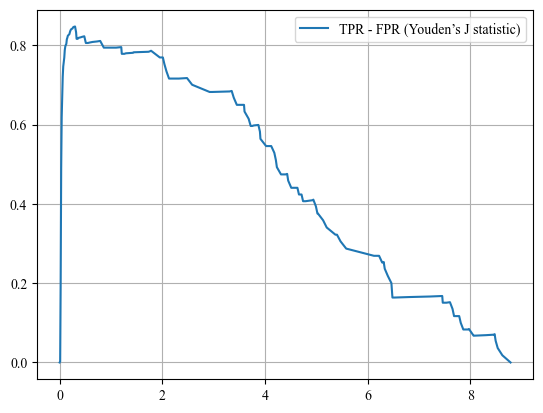

Optimal threshold: 0.3


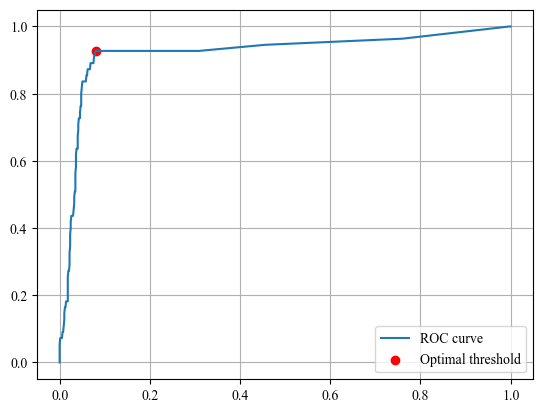

--- Test 1 ---
<class 'pandas.core.frame.DataFrame'>
Index: 862 entries, 0 to 878
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   COVID_swab_res   862 non-null    int64  
 1   IgG_Test1_titre  862 non-null    float64
 2   IgG_Test2_titre  862 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 26.9 KB


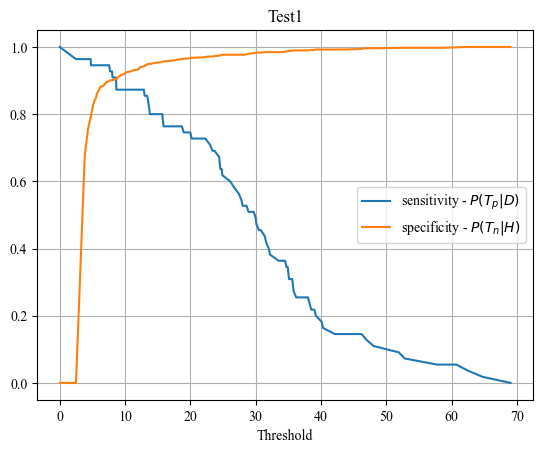

<Figure size 640x480 with 0 Axes>

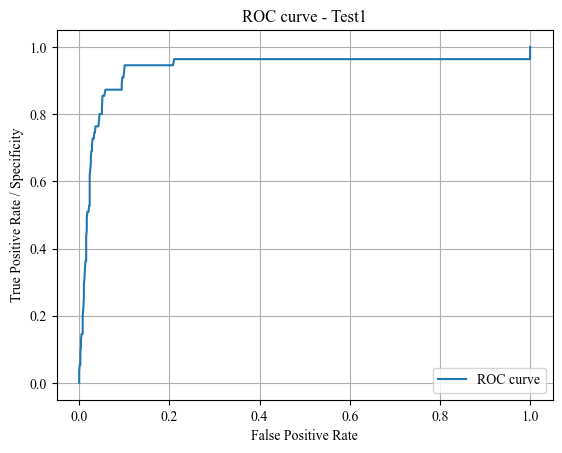

Manual AUC (Loop): 0.9358233497768376
Sklearn AUC: 0.9483673948790228


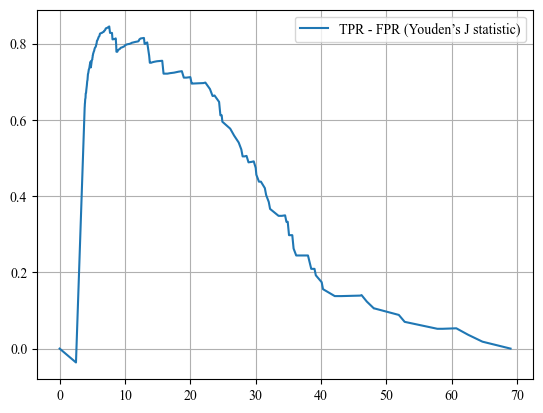

Optimal threshold: 7.59


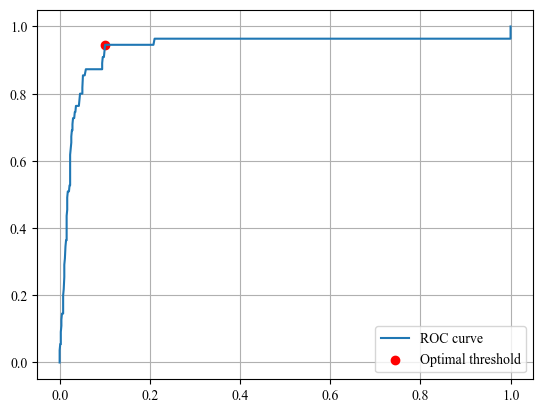


--- Comparison ---
Test 1: Optimal Threshold = 7.590, Sensitivity = 0.945, Specificity = 0.899
Test 2: Optimal Threshold = 0.300, Sensitivity = 0.927, Specificity = 0.920

--- AUC comparison ---
Test 1 AUC: 0.948
Test 2 AUC: 0.938
Test 1 performs better in terms of AUC.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster as sk
from sklearn import metrics
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import MinMaxScaler

plt.rcParams["font.family"] = "Times New Roman"
plt.close('all')

class Covid():
    def __init__(self):
        self.data = "covid_serological_results.csv"

    def DataAnalysis(self,Test):
        self.Test = Test
        # remove the unceratin swab results and set 1: positive / 0: negative
        xx = pd.read_csv(self.data)
        xx = xx[xx.COVID_swab_res!=1] # remove unclear results
        xx.loc[xx.COVID_swab_res==2,"COVID_swab_res"] = 1
        # data Analysis
        xx.describe()
        xx.info()
        #pd.plotting.scatter_matrix(xx, alpha=0.2)
        #xx.hist()
        # DBSCAN to remove outliers
        scaler = MinMaxScaler()
        X = xx[['IgG_Test1_titre', 'IgG_Test2_titre']]
        X_norm = scaler.fit_transform(X)
        db = sk.DBSCAN(eps=0.05, min_samples=5)
        labels = db.fit_predict(X_norm)
        xx = xx[labels != -1]
        # values of the Test 
        self.swab = xx.COVID_swab_res.values # results from swab: 0 = no illness, 1 = illness
        if Test == "Test1":
            self.Test_value = xx.IgG_Test1_titre.values
        elif Test == "Test2":
            self.Test_value = xx.IgG_Test2_titre.values

    def Sensitivity_Specificity(self):
        x = self.Test_value
        y = self.swab

        # count number of ill and healthy patients
        x0 = x[y==0] # test results for healthy patients
        x1 = x[y==1] # test results for ill patients
        Np = np.sum(y==1) # number of ill patients
        Nn = np.sum(y==0) # number of healthy patients

        # Thresholds: sorted values of the test + 0
        self.thresholds = np.unique(np.append(x, 0)) #unique: remove duplicates, sort in ascending order
        
        self.sensitivity = []
        self.specificity = []

        for thresh in self.thresholds: 
            n1 = np.sum(x1 > thresh) # number of true positives for the given thresh
            sens = n1/Np # sensitivity
            self.sensitivity.append(sens)
            n0 = np.sum(x0 < thresh) # number of true negatives
            spec = n0/Nn # specificity
            self.specificity.append(spec)
    
        plt.figure()
        plt.plot(self.thresholds, self.sensitivity, label='sensitivity - $P(T_p|D)$')
        plt.plot(self.thresholds, self.specificity, label='specificity - $P(T_n|H)$')
        plt.xlabel('Threshold')
        plt.grid()
        plt.legend()
        plt.title(self.Test)
        plt.show()
        plt.figure()

    def ROC(self):
        self.FPR = 1 - np.array(self.specificity)

        # plot ROC
        plt.figure()
        plt.plot(self.FPR, self.sensitivity, label = 'ROC curve')
        plt.legend()
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate / Specificity')
        plt.grid()
        plt.title('ROC curve - ' + self.Test)
        plt.show()

        # Manually calculation of Area Under the Curve (AUC)
        # Sort FPR in ascending order for integration
        sorted_index = np.argsort(self.FPR)
        fpr_sorted = self.FPR[sorted_index]
        tpr_sorted = np.array(self.sensitivity)[sorted_index]
        AUC_manual = 0.0
        for i in range(len(fpr_sorted) - 1):
            AUC_i = ((tpr_sorted[i+1] + tpr_sorted[i]) * (fpr_sorted[i+1] - fpr_sorted[i])/2)
            AUC_manual += AUC_i

        print('Manual AUC (Loop):', AUC_manual)
    
        # AUC sklearn
        fpr, tpr, thresh = metrics.roc_curve(self.swab, self.Test_value, pos_label=1)
        AUC = roc_auc_score(self.swab, self.Test_value)
        print('Sklearn AUC:', AUC)
        self.AUC = AUC

    def SetThreshold(self):
        # maximize Youden’s J statistic
        j = np.array(self.sensitivity) - (1 - np.array(self.specificity))
        plt.figure()
        plt.plot(self.thresholds, j, label = 'TPR - FPR (Youden’s J statistic)')
        plt.legend()
        plt.grid()
        plt.show()

        # get the optimal threshold
        max_j = np.argmax(j)
        optimal_threshold = self.thresholds[max_j]
        print('Optimal threshold:', optimal_threshold)

        # plot the ROC with a poin in optimal threshold
        plt.figure()
        plt.plot(self.FPR, self.sensitivity, label = 'ROC curve')
        plt.scatter(self.FPR[max_j], self.sensitivity[max_j], color = 'red', label = 'Optimal threshold')
        plt.legend()
        plt.grid()
        plt.show()
        
        return optimal_threshold, self.sensitivity[max_j], self.specificity[max_j]

if __name__ == "__main__":
    instance = Covid()
    
    print("--- Test 2 ---")
    instance.DataAnalysis("Test2")
    instance.Sensitivity_Specificity()
    instance.ROC()
    AUC_test2 = instance.AUC
    opt_th2, sens2, spec2 = instance.SetThreshold()

    print("--- Test 1 ---")
    instance.DataAnalysis("Test1")
    instance.Sensitivity_Specificity()
    instance.ROC()
    AUC_test1 = instance.AUC
    opt_th1, sens1, spec1 = instance.SetThreshold()

    print("\n--- Comparison ---")
    print(f"Test 1: Optimal Threshold = {opt_th1:.3f}, Sensitivity = {sens1:.3f}, Specificity = {spec1:.3f}")
    print(f"Test 2: Optimal Threshold = {opt_th2:.3f}, Sensitivity = {sens2:.3f}, Specificity = {spec2:.3f}")
    print("\n--- AUC comparison ---")
    print(f"Test 1 AUC: {AUC_test1:.3f}")
    print(f"Test 2 AUC: {AUC_test2:.3f}")

    if AUC_test1 > AUC_test2:
        print("Test 1 performs better in terms of AUC.")
    elif AUC_test2 > AUC_test1:
        print("Test 2 performs better in terms of AUC.")
    else:
        print("The two tests are equivalent in terms of AUC.")

